# Adaptive Portfolios

## This notebook demonstrates how to replicate Adaptive portfolios using the [Unravel API](https://unravel.finance).

Licence: MIT

---

### About Unravel
Unravel (https://unravel.finance) is a quantitative research firm providing predictive alternative data in the digital assets space. We provide proprietary cross-sectional factors and operate market-neutral, multi-factor portfolios via licencing deals or SMAs.

---

### **Prerequisites to run this notebook**

**For immediate, trial access:**

Create an account at [Unravel Finance](https://unravel.finance) and use the API key.
Without a subscription, you won't have access to the last 30 days of data.

**For limited time full access**:

You can request a Proof of Concept API key at [Unravel Finance POC form](https://unravel.finance/institutional).

> ⚙️ **Auto-generated** — this notebook was produced by `scripts/generate_portfolio_notebooks.py` from `00_adaptive-portfolios.ipynb`. The parameters below are the live composition of the Foundational Adaptive portfolio (`foundational_adaptive.40`) on unravel.finance. Edit the parameters cell to customise; rerun the script to regenerate from the template.

### Import Libraries

In [1]:
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import unravel_client

### Main Specification

Modify the parameters below to replicate the portfolio.
Please see the list of [Factors](https://unravel.finance/portfolios/40) that can be used.

- **UNRAVEL_API_KEY**:
     *   **Create a free account at [Unravel](https://unravel.finance) to get historical data with API key** <br/>
     (without subscription it returns data limited to 30 days in the past)
     *   or **Request a Proof of Concept API key that gives you live data** at [Unravel POC Form](https://unravel.finance/institutional)
     *   or Subscribe to a paid plan, see [Unravel Pricing](https://unravel.finance/pricing)


- **factors**: Factors to include in the multi-factor portfolio.
- **start_date**: Start date for the backtest.
- **end_date**: End date for the backtest.
- **universe_size**: The number of tickers to include in the portfolio.

In [2]:
load_dotenv()
UNRAVEL_API_KEY = os.getenv("UNRAVEL_API_KEY")

factor = "foundational"
start_date = "2020-01-01"
end_date = "2025-08-01"
universe_size = "40"

print(
    "**Parameters:**\n"
    f"factor: {factor}\n"
    f"start_date: {start_date}\n"
    f"end_date: {end_date}\n"
    f"universe_size: {universe_size}\n"
)
def filter_none(results: list[Any]) -> list[Any]:
    return [r for r in results if r is not None]

**Parameters:**
factor: foundational
start_date: 2020-01-01
end_date: 2025-08-01
universe_size: 40



### Backtest Functions

Core portfolio backtesting and performance calculation.

In [3]:

ReturnsDataFrame = pd.DataFrame
Returns = pd.Series
Signal = pd.Series


@dataclass
class PortfolioBacktestResult:
    portfolio_returns: Returns
    component_returns: ReturnsDataFrame
    transaction_costs: pd.Series
    lag: int

    def split(self, start_date, end_date) -> PortfolioBacktestResult:
        return PortfolioBacktestResult(
            portfolio_returns=self.portfolio_returns[start_date:end_date],
            component_returns=self.component_returns[start_date:end_date],
            transaction_costs=self.transaction_costs[start_date:end_date],
            lag=self.lag,
        )


def backtest_portfolio(
    weights: pd.DataFrame,
    underlying: ReturnsDataFrame,
    transaction_cost: float,
    lag: int,
) -> PortfolioBacktestResult:
    """
    Create returns from a signal and a target.
    """
    assert weights.columns.equals(underlying.columns), "Columns must match"
    underlying = underlying.loc[weights.index]
    weights = weights.fillna(0.0).reindex(underlying.index).ffill().copy()
    weights.columns = underlying.columns
    delta_pos = weights.diff(1).abs().fillna(0.0)
    costs = transaction_cost * delta_pos
    returns = (underlying * weights.shift(lag)) - costs
    portfolio_returns = returns.sum(axis="columns")

    transaction_costs = costs.sum(axis="columns")
    return PortfolioBacktestResult(
        portfolio_returns=portfolio_returns,
        component_returns=returns,
        transaction_costs=transaction_costs,
        lag=lag,
    )


def create_cross_sectional_bins(
    factor_data: pd.DataFrame, quantiles: int
) -> tuple[pd.DataFrame, pd.DataFrame]:
    factors_binned = factor_data.apply(
        lambda x: pd.qcut(x, q=quantiles, labels=False, duplicates="drop"),
        axis="columns",
    )
    weights = factors_binned.div(factors_binned.max(axis="columns"), axis="index")
    weights = weights.mul(2).sub(1)

    return weights.div(weights.abs().sum(axis="columns"), axis="index"), factors_binned


def average_elementwise(
    dfs: list[pd.DataFrame],
) -> pd.DataFrame:
    return pd.concat(dfs).groupby(level=0).mean().sort_index()


def plot_last_row_barplot(df: pd.DataFrame, title: str):
    last_row = df.iloc[-1].dropna().sort_values()
    plt.bar(last_row.index, last_row.values)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


def to_drawdown(prices: pd.Series) -> pd.Series:
    running_max = prices.cummax()
    return (prices - running_max) / running_max


def rebase(prices: pd.Series) -> pd.Series:
    """Rebase a price series to 1.0"""
    return prices / prices.iloc[0]


def plot_backtest_results(
    cumulative_returns: pd.Series,
    benchmark: pd.Series | None,
    portfolio: str,
    figsize=(12, 10),
):
    """
    Plot backtest results with performance chart and signal.

    Args:
        cumulative_returns (pd.Series): Series containing cumulative returns
        benchmark (pd.Series): Series containing benchmark data
        portfolio (str): Portfolio name/identifier
        figsize (tuple): Figure size as (width, height) in inches
    """
    show_benchmark = benchmark is not None
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=figsize, gridspec_kw={"height_ratios": [2, 1]}
    )

    ax1.plot(
        cumulative_returns.index,
        cumulative_returns,
        label="Portolio Cumulative Returns",
        color="darkBlue",
    )
    if show_benchmark:
        ax1.plot(
            benchmark.index,
            benchmark,
            label=f"Benchmark ({benchmark.name})",
            color="gray",
        )
    ax1.set_title("Performance of Portfolio", fontsize=14)
    ax1.legend()
    ax1.grid(True, axis="y", linestyle="--")

    ax2.plot(
        cumulative_returns.index,
        to_drawdown(cumulative_returns),
        label="Drawdown Portfolio",
        color="red",
    )
    if show_benchmark:
        ax2.plot(
            benchmark.index,
            to_drawdown(benchmark),
            label="Drawdown Benchmark",
            color="gray",
        )
    ax2.set_title(f"Portfolio {portfolio}")
    ax2.legend()
    ax2.grid(True, axis="y", linestyle="--")

    plt.tight_layout()
    plt.show()

    return fig, (ax1, ax2)

### Retrieving the historical universe (Top 40 Market Cap Crypto Assets)

To avoid any lookahead bias, the universe needs to be constructed on a rolling basis. We apply heavy volume & volatility filters to reduce the turnover of the universe further.

In [4]:
universe = unravel_client.get_historical_universe(
    size=universe_size,
    start_date=start_date,
    end_date=end_date,
    api_key=UNRAVEL_API_KEY,
)
tickers = list(universe.columns)

### Retrieve Price Data

Fetching underlying asset price data for backtesting.

In [5]:
underlying = unravel_client.get_prices(
    tickers=tickers,
    api_key=UNRAVEL_API_KEY,
    start_date=start_date,
    end_date=end_date,
)

# Filter out the tickers that don't have historical data on Binance
tickers = pd.Index(tickers).intersection(underlying.columns).to_list()

print(f"Number of tickers: {len(tickers)}")
print(f"Tickers: {tickers}")

Number of tickers: 147
Tickers: ['1INCH', 'AAVE', 'ADA', 'ALCH', 'ALGO', 'AMP', 'ANKR', 'APE', 'APT', 'AR', 'ARB', 'ASTER', 'ATOM', 'AVAX', 'AXS', 'BAL', 'BAND', 'BAT', 'BCH', 'BEAM', 'BLUR', 'BNB', 'BNT', 'BONK', 'BSV', 'BTC', 'CAKE', 'CELO', 'CFX', 'CHZ', 'COMP', 'CORE', 'CRO', 'CRV', 'CVC', 'DASH', 'DOGE', 'DOT', 'EGLD', 'ENA', 'ENJ', 'ENS', 'EOS', 'ETC', 'ETH', 'ETHW', 'FARTCOIN', 'FET', 'FIL', 'FLOKI', 'FLOW', 'FTN', 'GALA', 'GMT', 'GRT', 'HBAR', 'HNT', 'HOT', 'HYPE', 'ICP', 'ICX', 'IMX', 'INJ', 'IOST', 'IOTA', 'IP', 'JASMY', 'JST', 'JUP', 'KAS', 'KAVA', 'KSM', 'LAYER', 'LDO', 'LINK', 'LRC', 'LTC', 'LUNA', 'LUNC', 'MANA', 'MASK', 'MEMEFI', 'MINA', 'MKR', 'MNT', 'MORPHO', 'NEAR', 'NEO', 'NOT', 'OGN', 'OKB', 'OM', 'ONDO', 'ONE', 'ONT', 'OP', 'ORDI', 'PENGU', 'PEPE', 'POL', 'PUMP', 'QNT', 'QTUM', 'RENDER', 'RSR', 'RUNE', 'RVN', 'S', 'SAND', 'SEI', 'SHIB', 'SNT', 'SNX', 'SOL', 'STORJ', 'STX', 'SUI', 'SUSHI', 'SXP', 'T', 'TAO', 'THETA', 'TIA', 'TON', 'TRB', 'TRUMP', 'TRX', 'TWT', 'UMA'

### Fetching historical portfolio weights & risk overlay



In [6]:
portfolio_weights = unravel_client.get_portfolio_historical_weights(
    id=factor + ".40",
    api_key=UNRAVEL_API_KEY,
    start_date=start_date,
    end_date=end_date,
)
risk_overlay = unravel_client.get_risk_regime(
    overlay="crypto_trend_consensus",
    api_key=UNRAVEL_API_KEY,
    start_date=start_date,
    end_date=end_date,
)

<Axes: >

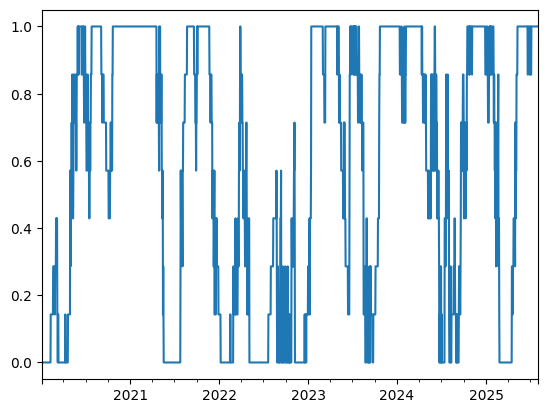

In [7]:
risk_overlay.plot()

By multiplying the portfolio weights with the risk overlay, we can essentially control the overall factor exposure, and take advantage of the effect that enhanced momentum exhibits: that it performs considerably better in a "crypto bull market".

In [8]:
risk_managed_portfolio_weights = portfolio_weights.mul(risk_overlay, axis=0)

### Portfolio Backtesting

Running the vectorized backtest with reasonable transaction costs (5bps). This ignores slippage & funding costs - the goal of the function is to be easily auditable.

/tmp/ipykernel_3108/3956817878.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  underlying=underlying[risk_managed_portfolio_weights.columns].pct_change(),
/tmp/ipykernel_3108/3956817878.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  underlying=underlying[portfolio_weights.columns].pct_change(),


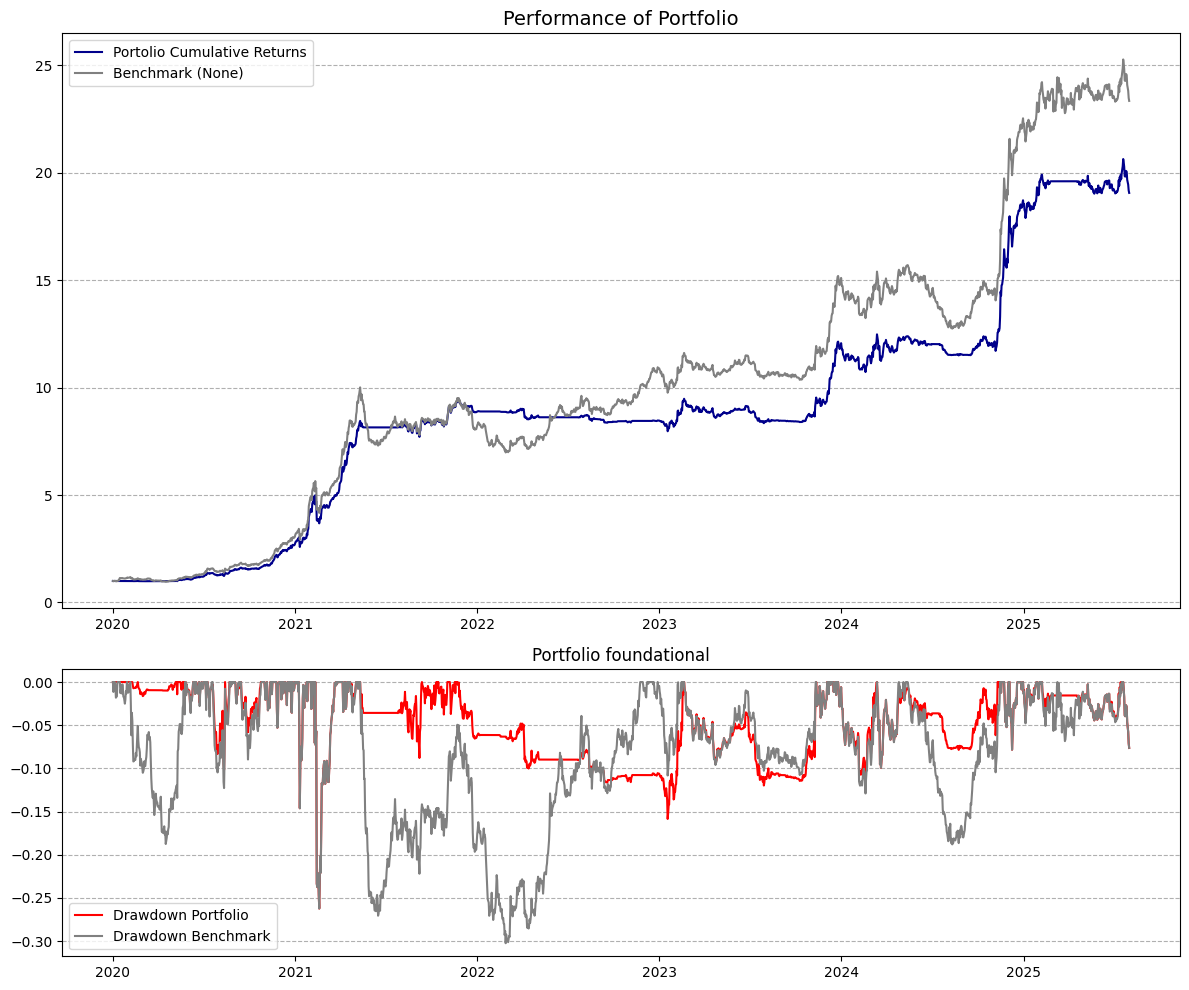

Sharpe Ratio (Original): 2.0809978199259445
Sharpe Ratio (with Risk overlay): 2.2488615117924287


In [9]:
result_riskoverlay = backtest_portfolio(
    weights=risk_managed_portfolio_weights,
    underlying=underlying[risk_managed_portfolio_weights.columns].pct_change(),
    transaction_cost=0.0005,
    lag=1,
)
result_original = backtest_portfolio(
    weights=portfolio_weights,
    underlying=underlying[portfolio_weights.columns].pct_change(),
    transaction_cost=0.0005,
    lag=1,
)
plot_backtest_results(
    rebase((1 + result_riskoverlay.portfolio_returns).cumprod()),
    rebase((1 + result_original.portfolio_returns).cumprod()),
    factor,
)
sharpe_ratio_original = (
    result_original.portfolio_returns.mean() / result_original.portfolio_returns.std() * np.sqrt(365)
)
sharpe_ratio = (
    result_riskoverlay.portfolio_returns.mean() / result_riskoverlay.portfolio_returns.std() * np.sqrt(365)
)
print(f"Sharpe Ratio (Original): {sharpe_ratio_original}")
print(f"Sharpe Ratio (with Risk overlay): {sharpe_ratio}")



The goal of this notebook is to demonstrate that it may not take much to actually create a multi-factor portfolio with great risk-adjusted returns in crypto, purposefully using the simplest possible techniques.

